<a href="https://colab.research.google.com/github/andrewmacc04/SJSU-Work/blob/main/Exercise2_ReACT_Code_OFFLINE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 2 – Code Generation with ReACT Prompting (Offline)

**Goal:** Demonstrate a ReACT style cycle:
Reason → Plan → Act (code) → Observe → Fix → Run again

**Offline note:** No API calls. We write the code ourselves, run it, observe, then improve it.


## ReACT Prompt (the prompt I would use)

**Reason:** Think about the task and edge cases  
**Plan:** Outline steps  
**Act:** Write code using only pandas + matplotlib with try/except  
**Observe:** Run and check output  
**Fix:** Improve code if something is wrong


In [4]:
# ---------------- Reason / Plan (student notes) ----------------
# Reason:
# I need a small dataset created in code, clean it, show stats, and make one plot.
# Edge cases: missing values, wrong dtypes, empty dataframe after cleaning.
#
# Plan:
# 1) Create dataframe
# 2) Convert numeric columns safely
# 3) Drop rows with missing values
# 4) Print cleaned head + describe()
# 5) Plot one chart with labels


Cleaned dataframe head:
  name  score  hours
0    A   10.0    1.0
1    B   15.0    2.0 

Summary table:
           score     hours
count   2.000000  2.000000
mean   12.500000  1.500000
std     3.535534  0.707107
min    10.000000  1.000000
25%    11.250000  1.250000
50%    12.500000  1.500000
75%    13.750000  1.750000
max    15.000000  2.000000 



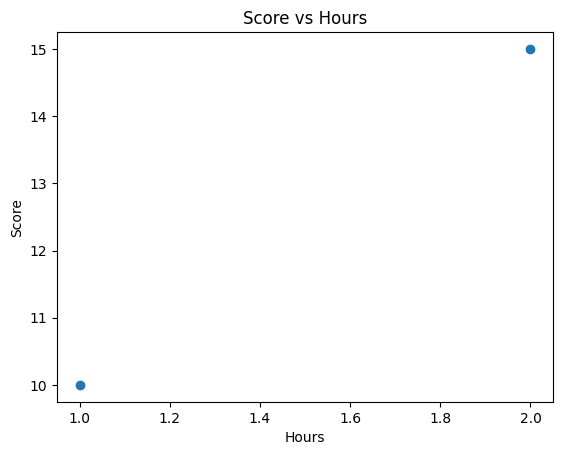

In [5]:
# ---------------- Act (Run 1) ----------------
import pandas as pd
import matplotlib.pyplot as plt

try:
    data = [
        {"name": "A", "score": "10", "hours": 1},
        {"name": "B", "score": " 15 ", "hours": 2},
        {"name": "C", "score": None, "hours": 3},
        {"name": "D", "score": "20", "hours": None},
    ]
    df = pd.DataFrame(data)

    # Convert score and hours into numeric
    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    df["hours"] = pd.to_numeric(df["hours"], errors="coerce")

    cleaned = df.dropna().copy()

    print("Cleaned dataframe head:")
    print(cleaned.head(), "\n")

    print("Summary table:")
    print(cleaned[["score", "hours"]].describe(), "\n")

    plt.figure()
    plt.scatter(cleaned["hours"], cleaned["score"])
    plt.title("Score vs Hours")
    plt.xlabel("Hours")
    plt.ylabel("Score")
    plt.show()

except Exception as e:
    print("Error:", e)


## Observe (Run 1)

- Output prints a cleaned dataframe and summary stats  
- Plot appears  
- One potential issue: if cleaning removes all rows, plotting will fail or show nothing


Cleaned dataframe head:
  name  score  hours
0    A   10.0    1.0
1    B   15.0    2.0 

Summary table:
           score     hours
count   2.000000  2.000000
mean   12.500000  1.500000
std     3.535534  0.707107
min    10.000000  1.000000
25%    11.250000  1.250000
50%    12.500000  1.500000
75%    13.750000  1.750000
max    15.000000  2.000000 



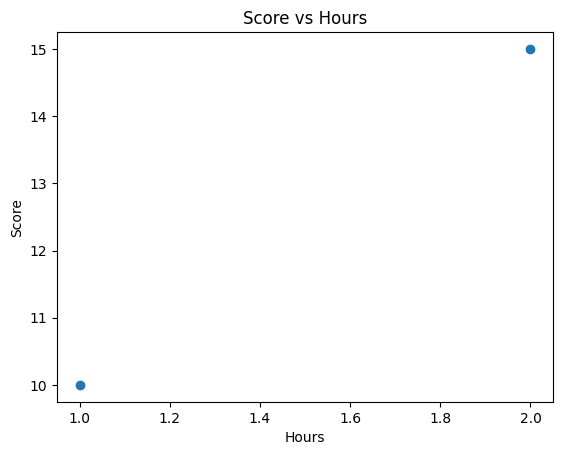

In [6]:
# ---------------- Fix (Run 2 improvement) ----------------
# Add a simple guard: if cleaned is empty, skip plot and print a message.

import pandas as pd
import matplotlib.pyplot as plt

try:
    data = [
        {"name": "A", "score": "10", "hours": 1},
        {"name": "B", "score": " 15 ", "hours": 2},
        {"name": "C", "score": None, "hours": 3},
        {"name": "D", "score": "20", "hours": None},
    ]
    df = pd.DataFrame(data)

    df["score"] = pd.to_numeric(df["score"], errors="coerce")
    df["hours"] = pd.to_numeric(df["hours"], errors="coerce")

    cleaned = df.dropna().copy()

    print("Cleaned dataframe head:")
    print(cleaned.head(), "\n")

    print("Summary table:")
    print(cleaned[["score", "hours"]].describe(), "\n")

    if cleaned.empty:
        print("No rows left after cleaning, so I skipped the plot.")
    else:
        plt.figure()
        plt.scatter(cleaned["hours"], cleaned["score"])
        plt.title("Score vs Hours")
        plt.xlabel("Hours")
        plt.ylabel("Score")
        plt.show()

except Exception as e:
    print("Error:", e)


### Evidence of iteration
- Run 1 worked, but I noticed an edge case (empty dataframe after cleaning)  
- Run 2 added a guard to handle that case cleanly
